# Benchmarking de Clasificadores

In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from IPython.display import display, HTML
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import warnings


PROJECT_ROOT = Path.cwd().parent
SRC_PATH     = PROJECT_ROOT / "src"
DATA_PATH    = PROJECT_ROOT / "data" / "telco_churn_preprocessed.parquet"
RESULTS_PATH    = PROJECT_ROOT / "results"

# Add src to Python path (only once)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from visual_diagnostics_toolkit import *
from model_evaluation_toolkit import plot_roc_curves

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

cols_ohe = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'PaymentMethod'
]

cols_le = ['Contract']

cols_num_scale = ['MonthlyCharges', 'TotalCharges']

cols_passthrough = ['tenure', 'SeniorCitizen']

df = pd.read_parquet(DATA_PATH)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def _render_figure(fig: plt.Figure, dpi: int = 100) -> None:
    """
    Encode a matplotlib figure as Base64 PNG and render it centered.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        The figure to render.
    dpi : int, optional
        Output resolution (default 100).
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=dpi)
    plt.close(fig)

    encoded = base64.b64encode(buf.getbuffer()).decode("ascii")

    display(HTML(
        f'<div style="text-align: center; width: 100%;">'
        f'<img src="data:image/png;base64,{encoded}"></div>'
    ))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_feature_importance(
    model,
    X: pd.DataFrame,
    feature_labels: list[str] | dict[str, str] = None,
    top_k: int = 10,
    label_pad: int = 15,
    xlim: tuple = None,
    tick_size: int = 12,
    annot_size: int = 12,
    figsize: tuple[int, int] = (8, 5),
    spanish: bool = True,
) -> None:
    """
    Plot tree-based feature importance with full styling control.

    This function extracts `feature_importances_` from a fitted model or pipeline
    and displays a horizontal bar chart of the top variables, excluding any with
    exactly zero importance.

    Parameters
    ----------
    model : sklearn estimator or Pipeline
        A fitted model with a `feature_importances_` attribute, or a Pipeline
        whose final step is a tree-based model.

    X : pd.DataFrame
        Feature matrix used to map column names if the model is not a pipeline.
        
    feature_labels : list of str or dict, optional
        A list of strings or dictionary to manually rename the plotted features. 
        If a list is provided, its length must match the final number of plotted 
        features, ordered from most important to least important.

    top_k : int, optional
        Number of top features to display
        (default ``10``).

    label_pad : int, optional
        Padding for axis labels.

    xlim : tuple, optional
        Manual limits for the x-axis.

    tick_size : int, optional
        Font size for axis ticks.

    annot_size : int, optional
        Font size for numeric annotations.

    figsize : tuple, optional
        Figure size in inches.

    spanish : bool, optional
        If True, display labels in Spanish.
        Default is ``True``.
    """
    # ------------------------------------------------------------------
    # 1. Extract importances and feature names
    # ------------------------------------------------------------------
    if hasattr(model, "steps"):
        classifier = model.steps[-1][1]
        if not hasattr(classifier, "feature_importances_"):
            raise ValueError("El estimador final del pipeline no tiene el atributo 'feature_importances_'.")
        
        importances = classifier.feature_importances_
        
        try:
            extracted_names = model[:-1].get_feature_names_out()
        except Exception:
            extracted_names = X.columns
    else:
        if not hasattr(model, "feature_importances_"):
            raise ValueError("El modelo no tiene el atributo 'feature_importances_'.")
        
        importances = model.feature_importances_
        extracted_names = X.columns

    if len(importances) != len(extracted_names):
        final_names = [f"Variable_{i}" for i in range(len(importances))]
    else:
        final_names = extracted_names

    df_all = pd.DataFrame({
        "Feature": final_names,
        "Importance": importances
    })

    # ------------------------------------------------------------------
    # 2. Select Top K (Filtrando importancias > 0)
    # ------------------------------------------------------------------
    df_top = (
        df_all[df_all["Importance"] > 0]
        .sort_values(by="Importance", ascending=True)
        .tail(top_k)
    ).copy() # .copy() para evitar SettingWithCopyWarning

    if df_top.empty:
        print(
            "Aviso: Ninguna variable tiene una importancia mayor a 0."
            if spanish else
            "Warning: No features have an importance greater than 0."
        )
        return

    # ------------------------------------------------------------------
    # 3. Renombrar variables en pantalla
    # ------------------------------------------------------------------
    if feature_labels is not None:
        if isinstance(feature_labels, dict):
            df_top["Feature"] = df_top["Feature"].replace(feature_labels)
        elif isinstance(feature_labels, list):
            if len(feature_labels) != len(df_top):
                raise ValueError(
                    f"Se proporcionaron {len(feature_labels)} nombres, pero hay "
                    f"{len(df_top)} variables a graficar. Revisa el tamaño de tu lista."
                )
            # Como df_top está ordenado de menor a mayor para el gráfico de barras horizontales,
            # revertimos la lista para que el primer nombre coincida con la variable más importante.
            df_top["Feature"] = feature_labels[::-1]

    # ------------------------------------------------------------------
    # 4. Plot
    # ------------------------------------------------------------------
    try:
        _apply_global_style()
        color = _PRIMARY_BLUE
    except NameError:
        color = "#1f77b4"

    fig, ax = plt.subplots(figsize=figsize, facecolor="white")

    bars = ax.barh(
        df_top["Feature"],
        df_top["Importance"],
        color=color,
        edgecolor="black",
        alpha=0.8
    )

    # ------------------------------------------------------------------
    # 5. Labels and axes
    # ------------------------------------------------------------------
    xlabel = (
        "Importancia Relativa"
        if spanish else
        "Relative Importance"
    )

    ylabel = "Atributos" if spanish else "Features"

    ax.set_xlabel(xlabel, fontsize=tick_size + 2, fontweight="bold", labelpad=label_pad)
    ax.set_ylabel(ylabel, fontsize=tick_size + 2, fontweight="bold", labelpad=label_pad)

    ax.tick_params(axis="both", labelsize=tick_size)

    # ------------------------------------------------------------------
    # 6. Axis limits
    # ------------------------------------------------------------------
    if xlim:
        ax.set_xlim(xlim)
    else:
        max_visible = df_top["Importance"].max()
        ax.set_xlim(0, max_visible * 1.15)

    # ------------------------------------------------------------------
    # 7. Annotations
    # ------------------------------------------------------------------
    offset = ax.get_xlim()[1] * 0.01

    for i, bar in enumerate(bars):
        val = df_top["Importance"].iloc[i]

        ax.text(
            val + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center",
            ha="left",
            fontsize=annot_size,
            fontweight="bold",
            color="#2c3e50"
        )

    # ------------------------------------------------------------------
    # 8. Styling
    # ------------------------------------------------------------------
    ax.xaxis.grid(True, linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    plt.tight_layout()
    
    try:
        _render_figure(fig, dpi=120)
    except NameError:
        plt.show()

In [5]:
import pandas as pd
from IPython.display import HTML, display

def display_top5(df):
    """
    Calcula la Mediana y el IQR de los pliegues, extrae el Top 5,
    y formatea el resultado como 'Mediana ± IQR' en una tabla HTML elegante.
    """
    # 1. Identificar columnas de folds y parámetros
    fold_cols = [c for c in df.columns if c.startswith('split')]
    param_cols = [c for c in df.columns if c.startswith('param_')]
    
    # 2. Calcular Mediana e IQR
    df_calc = df.copy()
    df_calc['Median_F1'] = df_calc[fold_cols].median(axis=1)
    df_calc['IQR_F1'] = df_calc[fold_cols].quantile(0.75, axis=1) - df_calc[fold_cols].quantile(0.25, axis=1)
    
    # 3. Ordenar y extraer el Top 5 basado en la Mediana
    top5 = df_calc.sort_values(by='Median_F1', ascending=False).head(5).copy()
    
    # 4. Crear la columna combinada XXX ± YYY
    top5['F1-Score'] = top5.apply(
        lambda row: f"{row['Median_F1']:.3f} ± {row['IQR_F1']:.3f}", axis=1
    )
    
    # 5. Seleccionar las columnas a mostrar (Parámetros + Métrica)
    cols_to_show = param_cols + ['F1-Score']
    top5_display = top5[cols_to_show].copy()
    
    # Limpiar prefijos largos de los parámetros para estética
    top5_display.columns = [
        c.replace('param_classifier__', '').replace('param_', '') if c.startswith('param_') else c 
        for c in top5_display.columns
    ]
    
    # 6. Aplicar estilos CSS para la tabla HTML
    styled_table = (
        top5_display.style
        .hide(axis='index')
        .set_table_styles([
            {
                'selector': '',
                'props': [
                    ('margin-left', 'auto'),
                    ('margin-right', 'auto'),
                    ('border-collapse', 'collapse')
                ]
            },
            {
                'selector': 'th',
                'props': [
                    ('text-align', 'center'),
                    ('background-color', '#f2f2f2'),
                    ('font-weight', 'bold'),
                    ('border', '1px solid black'),
                    ('padding', '8px')
                ]
            },
            {
                'selector': 'td',
                'props': [
                    ('text-align', 'center'),
                    ('border', '1px solid black'),
                    ('padding', '8px')
                ]
            },
            {
                'selector': 'caption',
                'props': [
                    ('caption-side', 'top'),
                    ('text-align', 'center'),
                    ('margin-bottom', '10px'),
                    ('color', 'black')
                ]
            }
        ])
    )
    
    # 7. Renderizar centrado
    display(
        HTML(
            "<div style='display:flex; justify-content:center; margin-bottom: 20px;'>"
            + styled_table.to_html()
            + "</div>"
        )
    )

In [6]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from IPython.display import display, HTML

def evaluate_model(
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    alert_threshold: float = 0.03,
    spanish: bool = False,
) -> Pipeline:
    """
    Train a complete production pipeline and evaluate its performance.

    Fits the provided ``sklearn.Pipeline`` (which should already have its hyperparameters 
    configured) exclusively on training data, ensuring no data leakage, and then evaluates 
    it on both training and test sets.

    Parameters
    ----------
    pipeline : sklearn.Pipeline
        A fully constructed pipeline (including preprocessing steps and the final estimator)
        with the desired hyperparameters already set. Must support ``predict_proba``.

    X_train : pd.DataFrame
        Training feature matrix.

    y_train : pd.Series
        Training labels (binary 0/1).

    X_test : pd.DataFrame
        Test feature matrix.

    y_test : pd.Series
        Test labels (binary 0/1).

    alert_threshold : float, optional
        Absolute Train–Test difference above which a metric is flagged
        with † (default ``0.03``).

    spanish : bool, optional
        If True, displays metric names and table labels in Spanish.
        Default is ``False``.

    Returns
    -------
    pipeline : sklearn.Pipeline
        Fully fitted pipeline ready for inference.
    """
    
    # 1. Entrenar el pipeline preconfigurado
    pipeline.fit(X_train, y_train)

    # 2. Generar Predicciones
    y_tr_pred = pipeline.predict(X_train)
    y_tr_prob = pipeline.predict_proba(X_train)[:, 1]

    y_te_pred = pipeline.predict(X_test)
    y_te_prob = pipeline.predict_proba(X_test)[:, 1]

    # 3. Configuración de idioma
    if spanish:
        metric_names = ["Exactitud", "Precisión", "Sensibilidad", "F1-Score", "ROC-AUC"]
        col_train = "Entrenamiento"
        col_test  = "Prueba"
        col_gap   = "Diferencia"
    else:
        metric_names = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
        col_train = "Train"
        col_test  = "Test"
        col_gap   = "Gap"

    metric_fns = [
        (metric_names[0], accuracy_score,  y_tr_pred, y_te_pred),
        (metric_names[1], precision_score, y_tr_pred, y_te_pred),
        (metric_names[2], recall_score,    y_tr_pred, y_te_pred),
        (metric_names[3], f1_score,        y_tr_pred, y_te_pred),
        (metric_names[4], roc_auc_score,   y_tr_prob, y_te_prob),
    ]

    # 4. Calcular métricas
    rows = []
    for name, fn, tr_arg, te_arg in metric_fns:
        tr_val = fn(y_train, tr_arg)
        te_val = fn(y_test,  te_arg)
        rows.append({
            "Metric": name,
            col_train: tr_val,
            col_test: te_val
        })

    df_summary = pd.DataFrame(rows)
    df_summary[col_gap] = (df_summary[col_train] - df_summary[col_test]).abs()

    # 5. Estilos de la tabla
    def _flag_gap(val: float) -> str:
        return f"{val:.3f}†" if val > alert_threshold else f"{val:.3f}"

    _TABLE_STYLES = [
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('border-collapse', 'collapse')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('font-weight', 'bold'), ('border', '1px solid black'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), ('padding', '8px')]}
    ]

    styled = (
        df_summary.style
        .hide(axis="index")
        .format({
            col_train: "{:.3f}",
            col_test: "{:.3f}",
            col_gap: _flag_gap
        })
        .set_table_styles(_TABLE_STYLES)
    )

    display(HTML(
        "<div style='text-align: center; width: 100%; margin-top: 10px;'>"
        + styled.to_html()
        + "</div>"
    ))

    return pipeline

In [7]:
_TABLE_STYLES = [
    {"selector": "",   "props": [("margin-left", "auto"), ("margin-right", "auto"),
                                  ("width", "auto")]},
    {"selector": "th", "props": [("background-color", "#f2f2f2"), ("color", "black"),
                                  ("border", "1px solid black"), ("padding", "10px"),
                                  ("text-align", "center")]},
    {"selector": "td", "props": [("border", "1px solid black"), ("padding", "10px"),
                                  ("text-align", "center")]},
]

def compare_models_table(
    models: list[tuple[str, Pipeline]],
    X_test: pd.DataFrame,
    y_test: pd.Series,
    spanish: bool = False,
    sort_by: str = "ROC-AUC",
    tie_breaker: str = "Accuracy"
) -> None:
    """
    Compare multiple fitted models on a common test set and display
    a styled performance table sorted dynamically by user-defined metrics.

    Models are ranked by:
        1. sort_by (descending)
        2. tie_breaker (descending, secondary condition)

    Parameters
    ----------
    models : list of (str, Pipeline)
        List of tuples containing model name and fitted pipeline.

    X_test : pd.DataFrame
        Test feature matrix.

    y_test : pd.Series
        True binary labels.

    spanish : bool, optional, default=False
        If True, displays metric names and model column in Spanish.

    sort_by : str, optional, default="ROC-AUC"
        The primary metric used to sort the models. 
        Valid options: "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC".

    tie_breaker : str, optional, default="Accuracy"
        The secondary metric used to sort the models if the primary metric ties.
        Valid options: "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC".

    Notes
    -----
    Metrics computed:
        - Accuracy (Exactitud)
        - Precision (Precisión)
        - Recall (Sensibilidad)
        - F1-Score
        - ROC-AUC
    """

    standard_metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

    if sort_by not in standard_metrics or tie_breaker not in standard_metrics:
        raise ValueError(f"sort_by and tie_breaker must be one of: {standard_metrics}")

    es_map = {
        "Accuracy": "Exactitud",
        "Precision": "Precisión",
        "Recall": "Sensibilidad",
        "F1-Score": "F1-Score",
        "ROC-AUC": "ROC-AUC"
    }

    if spanish:
        metric_names = [es_map[m] for m in standard_metrics]
        model_col = "Modelo"
        sort_col_1 = es_map[sort_by]
        sort_col_2 = es_map[tie_breaker]
    else:
        metric_names = standard_metrics
        model_col = "Model"
        sort_col_1 = sort_by
        sort_col_2 = tie_breaker

    rows = []

    for name, pipeline in models:

        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        row = {
            model_col: name,
            metric_names[0]: accuracy_score(y_test, y_pred),
            metric_names[1]: precision_score(y_test, y_pred),
            metric_names[2]: recall_score(y_test, y_pred),
            metric_names[3]: f1_score(y_test, y_pred),
            metric_names[4]: roc_auc_score(y_test, y_prob),
        }

        rows.append(row)

    df_results = pd.DataFrame(rows)
    df_results = df_results.sort_values(
        by=[sort_col_1, sort_col_2],
        ascending=[False, False]
    )

    styled = (
        df_results.style
        .format({col: "{:.3f}" for col in df_results.columns if col != model_col})
        .hide(axis="index")
        .set_table_styles(_TABLE_STYLES)
    )

    display(HTML(
        "<div style='text-align: center; width: 100%; margin-top: 10px;'>"
        + styled.to_html()
        + "</div>"
    ))

In [8]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from statsmodels.stats.multitest import multipletests
from IPython.display import display, HTML

def _compute_delong_cov(y_true: np.ndarray, y_prob_1: np.ndarray, y_prob_2: np.ndarray) -> tuple[float, float]:
    """
    Computes the standard error (SE) and Z-statistic for the difference 
    between two ROC AUCs using DeLong's method.
    """
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    m, n = len(pos_idx), len(neg_idx)
    
    v10_1 = np.array([np.sum(y_prob_1[pos_idx] > y_prob_1[j]) + 0.5 * np.sum(y_prob_1[pos_idx] == y_prob_1[j]) for j in neg_idx]) / m
    v01_1 = np.array([np.sum(y_prob_1[i] > y_prob_1[neg_idx]) + 0.5 * np.sum(y_prob_1[i] == y_prob_1[neg_idx]) for i in pos_idx]) / n
    
    v10_2 = np.array([np.sum(y_prob_2[pos_idx] > y_prob_2[j]) + 0.5 * np.sum(y_prob_2[pos_idx] == y_prob_2[j]) for j in neg_idx]) / m
    v01_2 = np.array([np.sum(y_prob_2[i] > y_prob_2[neg_idx]) + 0.5 * np.sum(y_prob_2[i] == y_prob_2[neg_idx]) for i in pos_idx]) / n
    
    s10 = np.cov(v10_1, v10_2)[0, 1]
    s01 = np.cov(v01_1, v01_2)[0, 1]
    
    var_1 = np.var(v10_1) / n + np.var(v01_1) / m
    var_2 = np.var(v10_2) / n + np.var(v01_2) / m
    cov_12 = s10 / n + s01 / m
    
    var_diff = var_1 + var_2 - 2 * cov_12
    se = np.sqrt(np.maximum(var_diff, 1e-8)) 
    
    auc_1 = roc_auc_score(y_true, y_prob_1)
    auc_2 = roc_auc_score(y_true, y_prob_2)
    diff = auc_1 - auc_2
    z = diff / se
    
    return se, z

def compare_delong(
    models: list[tuple[str, Pipeline]],
    X_test: pd.DataFrame,
    y_test: pd.Series,
    n_bootstraps: int = 2000,
    alpha: float = 0.05,
    spanish: bool = False
) -> None:
    """
    Performs a post-hoc pairwise DeLong test across multiple fitted models.
    """
    # Convertimos y_test para operaciones matemáticas, PERO dejamos X_test intacto
    y_test_arr = y_test.values if isinstance(y_test, pd.Series) else y_test
    
    probs = {}
    aucs = {}
    for name, pipeline in models:
        # Aquí pasamos X_test directamente (conservando nombres de columnas)
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        probs[name] = y_prob
        aucs[name] = roc_auc_score(y_test_arr, y_prob)

    rows = []
    p_values_raw = []
    
    for (name1, name2) in combinations(probs.keys(), 2):
        prob1 = probs[name1]
        prob2 = probs[name2]
        
        auc1, auc2 = aucs[name1], aucs[name2]
        diff = auc1 - auc2
        
        se, z = _compute_delong_cov(y_test_arr, prob1, prob2)
        p_val = 2 * stats.norm.sf(np.abs(z)) 
        p_values_raw.append(p_val)
        
        boot_diffs = []
        for _ in range(n_bootstraps):
            indices = resample(np.arange(len(y_test_arr)))
            y_true_b = y_test_arr[indices]
            if len(np.unique(y_true_b)) < 2:
                continue
            
            auc1_b = roc_auc_score(y_true_b, prob1[indices])
            auc2_b = roc_auc_score(y_true_b, prob2[indices])
            boot_diffs.append(auc1_b - auc2_b)
            
        lb = np.percentile(boot_diffs, (alpha / 2) * 100)
        ub = np.percentile(boot_diffs, (1 - alpha / 2) * 100)
        
        rows.append({
            "Model 1": name1,
            "Model 2": name2,
            "AUC (L1)": auc1,
            "AUC (L2)": auc2,
            "Difference": diff,
            "SE": se,
            "Z": z,
            "LB": lb,
            "UB": ub
        })
        
    df_results = pd.DataFrame(rows)
    
    _, pvals_corrected, _, _ = multipletests(p_values_raw, alpha=alpha, method='holm')
    
    formatted_p = []
    for p in pvals_corrected:
        if p < 0.001:
            formatted_p.append("<0.001***")
        elif p < 0.01:
            formatted_p.append(f"{p:.3f}**")
        elif p < 0.05:
            formatted_p.append(f"{p:.3f}*")
        else:
            formatted_p.append(f"{p:.3f}")
            
    df_results.insert(7, "p", formatted_p)

    if spanish:
        rename_map = {
            "Model 1": "Modelo 1",
            "Model 2": "Modelo 2",
            "Difference": "Diferencia"
        }
        df_results = df_results.rename(columns=rename_map)

    sort_col = "Diferencia" if spanish else "Difference"
    df_results = df_results.sort_values(by=sort_col, ascending=False, key=abs)

    numeric_cols = [col for col in df_results.columns if col not in ["Model 1", "Model 2", "Modelo 1", "Modelo 2", "p"]]
    
    styled = (
        df_results.style
        .format({col: "{:.3f}" for col in numeric_cols})
        .hide(axis="index")
        .set_table_styles(_TABLE_STYLES) 
    )

    display(HTML(
        "<div style='text-align: center; width: 100%; margin-top: 10px;'>"
        + styled.to_html()
        + "</div>"
    ))

# Introducción

Tras la caracterización estadística del dataset, esta fase se centra en la construcción de un ecosistema de modelado bajo estándares de alta fidelidad científica, donde el desafío técnico principal es la mitigación de la fuga de datos (*Data Leakage*). En el ámbito clínico, este fenómeno ocurre cuando el conocimiento del conjunto de prueba contamina el entrenamiento a través de los parámetros de escalado o las correlaciones de la imputación *MICE*, lo que genera métricas artificialmente optimistas que colapsarían en un entorno hospitalario real. Para blindar este flujo, se implementó una arquitectura basada en *Pipelines* y *GridSearchCV*, la cual asegura que tanto las transformaciones como la optimización de hiperparámetros se ejecuten estrictamente sobre los pliegues de entrenamiento mediante validación cruzada. Este diseño modular facilita un benchmarking multimodelo que incluye **Regresión Logística**, **Random Forest**, **KNN** y **Gradient Boosting**, permitiendo generar un ranking comparativo que prioriza la estabilidad y la capacidad de generalización frente a la complejidad de los datos médicos.

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,

    random_state=42,
    stratify=y
)

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cols_ohe),
        ('cat_ord', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]), cols_le),
        ('num_robust', RobustScaler(), cols_num_scale),
        ('pass', 'passthrough', cols_passthrough)
    ]
)

# Entrenamiento sin fuga

Con el fin de estandarizar la experimentación, se ha consolidado el método `train_model`, el cual integra la codificación, la imputación y el escalado en un *Pipeline de entrenamiento seguro*. Este flujo garantiza que todas las transformaciones de datos se ejecuten de forma estanca durante la validación cruzada, evitando sesgos por fuga de información en cada iteración. En las secciones siguientes se entrenarán múltiples modelos de clasificación con el propósito de comparar su rendimiento frente al SVC bajo estas condiciones de integridad metodológica.

Para la optimización de los hiperparámetros se ha seleccionado el área bajo la curva (ROC-AUC) como métrica principal, dado que permite evaluar la capacidad de discriminación del modelo de forma global, independientemente del umbral de clasificación seleccionado. Siguiendo la metodología establecida, se utiliza un esquema de validación cruzada estratificada (*Stratified K-Fold*) de 10 pliegues. Esta elección asegura que la proporción de las clases se mantenga constante en cada partición de entrenamiento y validación, aportando mayor robustez estadística al proceso y facilitando una comparación equitativa entre los diversos algoritmos.

Adicionalmente, para identificar si los estimadores presentan indicios de sobreajuste (*overfitting*) o subajuste (*underfitting*), se implementa un umbral de tolerancia del $3\%$ al comparar el rendimiento entre las particiones de entrenamiento y validación. Si bien este umbral empírico no constituye una prueba definitiva, proporciona un indicador cuantitativo útil sobre la estabilidad de los hiperparámetros y la capacidad de generalización de cada algoritmo frente a datos no observados.

:::{admonition} Nota Metodológica: Diagnóstico de Estabilidad y Generalización
:class: note

La integridad de un modelo clínico se mide por su capacidad de generalización, es decir, qué tan bien funciona con pacientes que nunca ha "visto". Para evaluar esto, analizamos la diferencia o gap entre el rendimiento en la muestra de entrenamiento (*Train*) y la de prueba (*Test*):

* **Overfitting (Sobreajuste):** Se identifica cuando el modelo presenta un desempeño superior en entrenamiento pero decae en prueba. En este protocolo, adoptamos un umbral crítico del $3\%$ ($0.030$) como marcador de alerta. Un gap mayor a este valor (marcado con el símbolo $\dagger$ en nuestras tablas) sugiere que el modelo ha memorizado ruidos específicos de la muestra original y perderá fiabilidad en la práctica clínica real.

* **Underfitting (Subajuste):** Ocurre cuando el rendimiento es consistentemente bajo en ambas muestras, indicando que el algoritmo es demasiado simple para capturar la complejidad del riesgo cardiovascular.

Es fundamental entender que este umbral del 3% no es una regla universal de la naturaleza, sino un marcador de calidad metodológica en ciencia de datos. En medicina, un modelo con un AUC alto pero con un gap de inestabilidad elevado es menos preferible que uno con métricas ligeramente menores pero más consistentes, ya que la estabilidad garantiza que las decisiones médicas sean predecibles y seguras para la población general.

:::

## Árbol de Decisión

Con el objetivo de establecer un punto de comparación sólido y fundamentado, se inicia el análisis con el `Árbol de Decisión`. Este modelo funciona como el benchmark o línea base de interpretabilidad, dado que permite la visualización de una estructura jerárquica de reglas lógicas que conducen a la clasificación del fenómeno estudiado. Si el despliegue de arquitecturas de ensamble con mayor densidad paramétrica (como `XGBoost` o `CatBoost`) no logra superar significativamente el desempeño de este clasificador, la ganancia marginal en las métricas no justificaría el incremento en la complejidad computacional y la pérdida de la transparencia directa que ofrece un árbol único.

En esta fase, se evalúan diversas configuraciones para el `Árbol de Decisión`, aplicando un enfoque de poda parsimonioso para determinar el **F1-Score** base. Cualquier arquitectura posterior deberá demostrar una mejora sustancial en esta métrica para ser considerada una alternativa preferible frente a la robustez y capacidad descriptiva de este benchmark inicial.

In [8]:
file_path = RESULTS_PATH / "grid_results_dt_20260508_0506.csv"
df_dt = pd.read_csv(file_path)

In [20]:
model_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
pipeline_dt = Pipeline(steps=[('preprocessor', preprocessor),('classifier', model_dt)])

param_grid_dt = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10, 20],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_features': [None, 'sqrt', 'log2']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dt = GridSearchCV(estimator=pipeline_dt, param_grid=param_grid_dt, scoring='f1', cv=cv_strategy, n_jobs=-1, verbose=2)
grid_dt.fit(X_train, y_train)
results_df_dt = pd.DataFrame(grid_dt.cv_results_)
cols_interes = [c for c in results_df_dt.columns if c.startswith('param_') or c.startswith('split')]
df_dt = results_df_dt[cols_interes]

display_top5(df_dt)

criterion,max_depth,max_features,min_samples_leaf,min_samples_split,F1-Score
gini,3,nan,1,2,0.619 ± 0.012
gini,3,nan,1,10,0.619 ± 0.012
entropy,3,nan,20,20,0.619 ± 0.012
entropy,3,nan,20,10,0.619 ± 0.012
entropy,3,nan,20,2,0.619 ± 0.012


Los resultados de la validación cruzada indican que el `Árbol de Decisión` establece una línea base de $0.619 \pm 0.012$ en el F1-Score. Este valor representa el punto de partida para la capacidad predictiva del proyecto, superando la aleatoriedad estadística al emplear las variables del conjunto de datos para la generación de reglas lógicas. Se observa una estabilidad notable entre las mejores configuraciones, donde tanto el criterio de *Gini* como el de *entropia* convergen en el mismo desempeño bajo una profundidad máxima limitada de $3$ niveles. Esta convergencia sugiere que, para este nivel de complejidad estructural, el modelo captura patrones consistentes independientemente de la métrica de pureza o las variaciones en el número mínimo de muestras por nodo. Con el fin de evaluar la capacidad de generalización del modelo frente a datos no observados, a continuación se presentan los resultados obtenidos en la muestra de prueba.

In [13]:
model_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42, criterion='gini', max_depth=3,
    min_samples_leaf=1, min_samples_split=2)

pipeline_dt_final = Pipeline(steps=[('preprocessor', preprocessor),('classifier', model_dt)])

pipeline_tree = evaluate_model(pipeline=pipeline_dt_final, X_train=X_train, y_train=y_train, X_test=X_test,
    y_test=y_test, spanish=True)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.755,0.749,0.006
Precisión,0.526,0.518,0.008
Sensibilidad,0.764,0.758,0.006
F1-Score,0.623,0.615,0.008
ROC-AUC,0.825,0.821,0.004


Tal como se observa en los resultados de la muestra de prueba, el modelo de `Árbol de Decisión` alcanza un **F1-Score** de $0.615$ y un **ROC-AUC** de $0.821$, demostrando un desempeño predictivo sólido y consistente. A diferencia del comportamiento típico asociado a este algoritmo, las métricas no presentan indicios de sobreajuste, dado que todas las diferencias entre las fases de entrenamiento y prueba se mantienen significativamente por debajo del umbral de tolerancia del $3\%$.La variación más alta se registra de forma compartida en la precisión y el F1-Score, con un diferencial de apenas $0.008$, mientras que las discrepancias en exactitud y **ROC-AUC** se limitan a $0.006$ y $0.004$, respectivamente. 


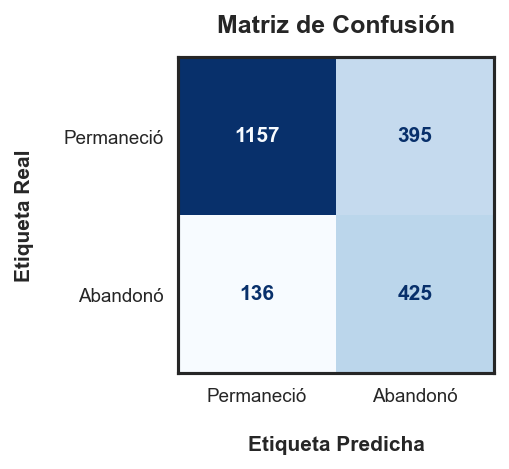

In [10]:
 plot_confusion_matrix(pipeline_tree, X_test, y_test, figsize = (3.5,3.5), labels = ["Permaneció", "Abandonó"],
                       label_size = 10, annot_size = 10, label_pad = 14)

La matriz de confusión del `Árbol de Decisión` individual revela las limitaciones estructurales de un modelo base frente a la complejidad del churn, pues aunque logra identificar a 425 clientes que efectivamente abandonaron, lo hace a costa de una imprecisión considerable al generar 395 falsos positivos, lo que demuestra que un solo árbol carece de la robustez necesaria para equilibrar la detección y la exactitud. Este escenario justifica la transición hacia modelos de ensamble como *Bagging* (`Random Forest`), necesario para reducir esta alta varianza y estabilizar las predicciones mediante el promedio de múltiples estimadores, y *Boosting* (`XGBoost`/`CatBoost`), requerido para corregir secuencialmente los errores de clasificación y aprender patrones sutiles de la clase minoritaria que un solo árbol no logra capturar sin comprometer seriamente la fiabilidad de los resultados.

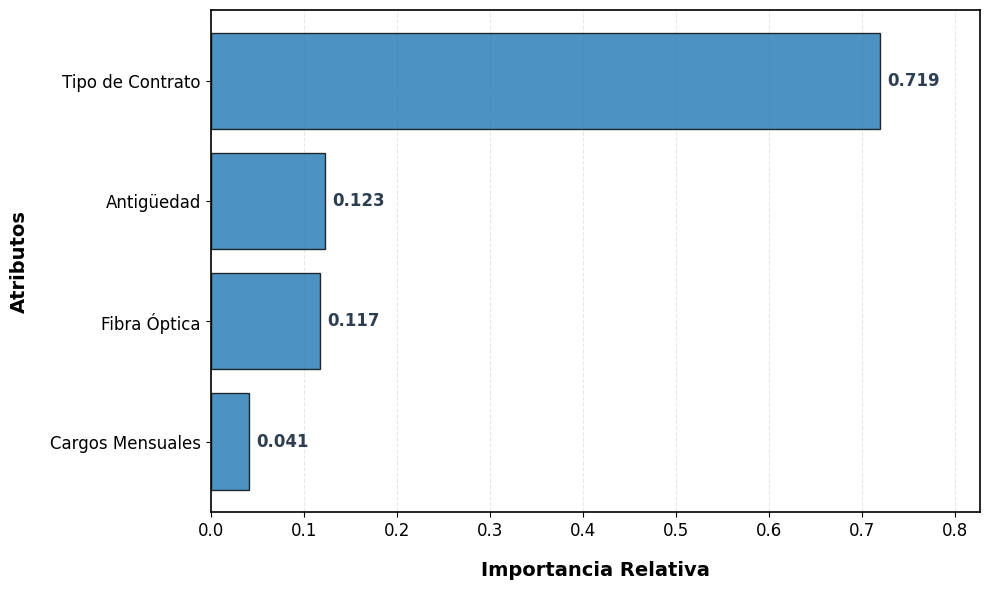

In [21]:
names = ["Tipo de Contrato", "Antigüedad", "Fibra Óptica", "Cargos Mensuales"]
plot_feature_importance(model=pipeline_tree, X=X_test, feature_labels=names, top_k=10, spanish=True, figsize=(10, 6))

Al analizar la importancia de los atributos en el Árbol de Decisión, se observa que el modelo concentra la mayor parte de su capacidad predictiva en un factor determinante: el Tipo de Contrato, con una importancia relativa de 0.719. Esta variable domina la ganancia de información inicial, sugiriendo que la estructura de compromiso contractual es el principal diferenciador entre la permanencia y el abandono. En un segundo plano, factores de fidelización y servicio como la Antigüedad y el uso de Fibra Óptica aportan una contribución marginal, mientras que los Cargos Mensuales tienen un impacto mínimo en la reducción de la impureza del árbol. Esta jerarquía indica que, para este clasificador base, la estabilidad del cliente está fuertemente ligada a la naturaleza del acuerdo legal más que a su comportamiento financiero inmediato.

## Random Forest

Se integra el modelo de `Random Forest` como un algoritmo de ensamble fundamentado en la técnica de Bagging (*Bootstrap Aggregating*). A diferencia de un árbol de decisión individual, este modelo construye múltiples árboles de forma independiente utilizando subconjuntos aleatorios tanto de las observaciones como de los predictores, diversificando así el proceso de aprendizaje.

La predicción final se obtiene mediante la agregación de los resultados de todo el bosque, un proceso diseñado para reducir la varianza y mitigar la sensibilidad al ruido observada en clasificadores individuales. Esta arquitectura permite estabilizar métricas críticas como el **F1-Score** y el **ROC-AUC** sin sacrificar la capacidad de capturar interacciones complejas entre las variables, ofreciendo un balance robusto entre sesgo y varianza para avanzar en el desarrollo del experimento

In [14]:
file_path = RESULTS_PATH / "grid_results_rf_20260508_0428.csv"
df_rf = pd.read_csv(file_path)

In [21]:
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 3, 5],
    'classifier__max_features': ['sqrt', 'log2']
}

pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model_rf)])
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(estimator=pipeline_rf, param_grid=param_grid_rf, scoring='f1', cv=cv_strategy, n_jobs=-1, verbose=2)

grid_rf.fit(X_train, y_train)
results_df = pd.DataFrame(grid_rf.cv_results_)
cols_interes = [c for c in results_df.columns if c.startswith('param_') or c.startswith('split')]
df_rf = results_df[cols_interes]

display_top5(df_rf)

max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,F1-Score
7,sqrt,1,5,300,0.634 ± 0.048
7,sqrt,3,2,200,0.633 ± 0.042
7,sqrt,3,5,200,0.633 ± 0.042
7,sqrt,3,5,300,0.633 ± 0.047
7,sqrt,3,2,300,0.633 ± 0.047


Los resultados de la hiperparametrización para el `Random Forest` reflejan un desempeño óptimo al alcanzar un **F1-Score** de $0.634 \pm 0.048$ en su mejor configuración. La convergencia unánime hacia una profundidad máxima de $7$ niveles y el uso de la raíz cuadrada de las características (*sqrt*) en todas las combinaciones superiores confirma que este nivel de complejidad estructural es el más efectivo para extraer patrones significativos de los datos. Tras el análisis de la malla, se seleccionó la configuración que utiliza 300 estimadores y una muestra mínima por hoja, al presentar el valor central de **F1-Score** más elevado del experimento, lo que sugiere una capacidad adecuada del bosque para promediar las estimaciones individuales y estabilizar la predicción final.

In [22]:
model_rf = RandomForestClassifier(n_estimators=300, max_depth=7, max_features='sqrt', min_samples_leaf=1, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=2)

pipeline_rf_final = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model_rf)])

pipeline_forest = evaluate_model(pipeline=pipeline_rf_final, X_train=X_train, y_train=y_train, X_test=X_test,
    y_test=y_test, spanish=True)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.780,0.757,0.024
Precisión,0.557,0.528,0.030
Sensibilidad,0.835,0.800,0.035†
F1-Score,0.669,0.636,0.033†
ROC-AUC,0.887,0.843,0.044†


Al evaluar el desempeño del modelo `Random Forest` en la muestra de prueba, se registra un **F1-Score** de $0.636$ y un ROC-AUC de $0.843$, superando el rendimiento obtenido por el Árbol de Decisión individual. No obstante, el ensamble presenta ligeros indicios de sobreajuste, con diferenciales que superan el umbral de tolerancia del $3\%$ en métricas como la sensibilidad ($0.035$) y el **F1-Score** ($0.033$), lo que les otorga la marca de alerta ($\dagger$). A pesar de estas variaciones, la pérdida de capacidad de clasificación se considera mínima y es un comportamiento esperable dado el volumen de $300$ estimadores utilizado para capturar la estructura de los datos. 


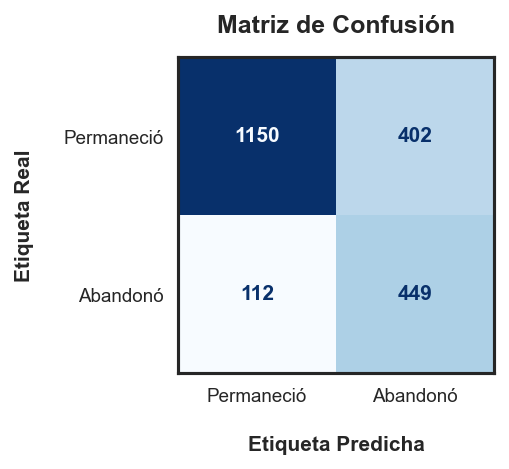

In [14]:
 plot_confusion_matrix(pipeline_forest, X_test, y_test, figsize = (3.5,3.5), labels = ["Permaneció", "Abandonó"],
                       label_size = 10, annot_size = 10, label_pad = 14)

La evalución de la matriz de confusión del modelo demuestra una mejora técnica superior respecto al `árbol de decisión` individual, ya que logra identificar correctamente a $449$ clientes en riesgo de fuga y reduce drásticamente los falsos negativos a solo $112$. Este avance confirma que el modelo de ensamble logra incrementar la capacidad de discriminación global al capturar una mayor proporción de abandonos reales que el estimador base. En balance, se mantiene la hipótesis de que este enfoque de *bagging* aporta una mayor robustez predictiva para la estrategia de retención, a pesar de no alcanzar la estabilidad extrema demostrada por la frontera del `Árbol de Decisión` previo en este conjunto de datos específico.

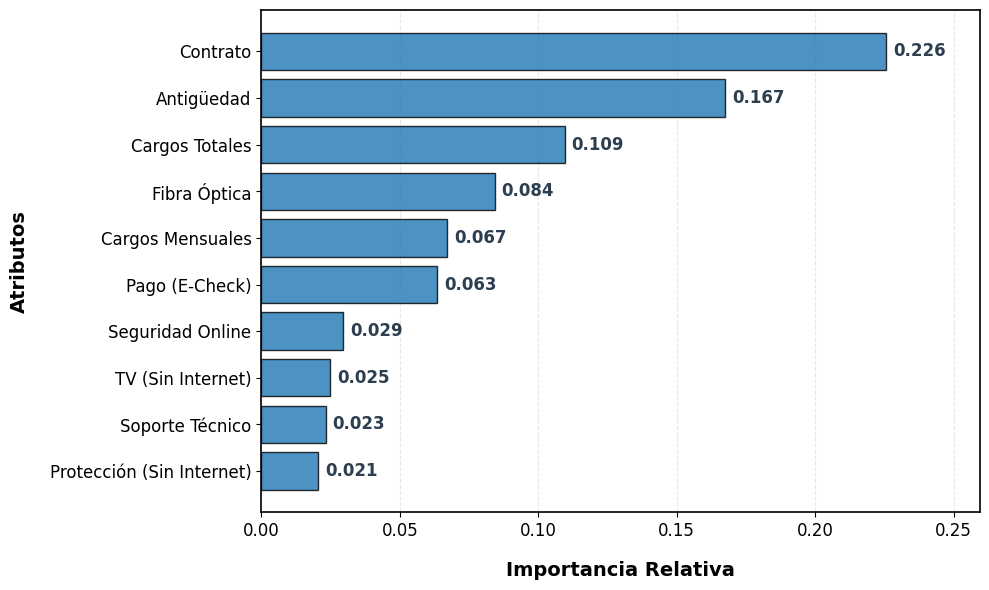

In [28]:
names = ["Contrato", "Antigüedad", "Cargos Totales", "Fibra Óptica", "Cargos Mensuales", "Pago (E-Check)",
         "Seguridad Online", "TV (Sin Internet)", "Soporte Técnico", "Protección (Sin Internet)"]
plot_feature_importance(model=pipeline_forest, X=X_test, feature_labels=names, top_k=10, spanish=True, figsize=(10, 6))

A diferencia del `Árbol de Decisión`, donde la capacidad predictiva se concentraba casi exclusivamente en una sola variable, el `Random Forest` presenta una distribución mucho más equilibrada y diversificada de la importancia de los atributos. Aunque el Contrato sigue encabezando la jerarquía, su predominio es considerablemente menor, permitiendo que factores como la Antigüedad y los Cargos Totales adquieran un peso relevante en la toma de decisiones del modelo. Esta transición hacia un esquema multivariable sugiere que el ensamble logra capturar patrones más complejos y matizados del comportamiento del cliente, integrando dimensiones financieras y de permanencia histórica que el árbol individual omitía. En consecuencia, el Random Forest ofrece una visión integral del `churn`, donde la estabilidad no depende únicamente del acuerdo legal, sino de una combinación crítica entre el ciclo de vida del usuario y su volumen de facturación acumulado.

##  Gradient Boosting

Como fase inicial en el estudio de los modelos de boosting, se entrena el algoritmo de `XGBoost` bajo el principio de aprendizaje secuencial, el cual construye modelos de manera sucesiva para corregir los errores residuales de las iteraciones previas mediante el descenso de gradiente. Esta capacidad de refinamiento iterativo permite capturar patrones de alta complejidad y relaciones no lineales sutiles en los datos tabulares, posicionándolo como uno de los clasificadores más potentes del experimento. No obstante, requiere una calibración precisa de la tasa de aprendizaje (*learning rate*) y el número de etapas para garantizar una generalización estable, representando el primer exponente de las arquitecturas de potenciación de gradiente que se analizarán antes de proceder con variantes como `LightGBM` o `CatBoost`.

In [22]:
file_path = RESULTS_PATH / "grid_results_xgb_20260508_0525.csv"
df_xgb = pd.read_csv(file_path)

In [23]:
pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor),('classifier', PuristXGBClassifier())])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200, 300, 400],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.4, 0.6, 0.8],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_xgb = GridSearchCV(estimator=pipeline_xgb, param_grid=param_grid_xgb, scoring='f1', cv=cv_strategy, n_jobs=-1, verbose=2)
grid_xgb.fit(X_train, y_train)
results_df = pd.DataFrame(grid_xgb.cv_results_)
cols_interes = [c for c in results_df.columns if c.startswith('param_') or c.startswith('split')]
raw_results = results_df[cols_interes]

display_top5(df_xgb)

colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,subsample,F1-Score
0.800000,0.050000,7,1,200,0.400000,0.635 ± 0.045
0.800000,0.050000,3,1,100,0.400000,0.635 ± 0.041
1.000000,0.010000,7,5,100,0.800000,0.634 ± 0.028
0.800000,0.010000,5,3,100,0.400000,0.634 ± 0.041
1.000000,0.050000,7,3,200,0.400000,0.631 ± 0.029


Los resultados de la hiperparametrización para el `XGBoost` revelan buen desempeño, alcanzando un F1-Score promedio de $0.635 \pm 0.041$. Si bien la primera configuración de la malla presenta el mismo valor central de rendimiento, se opta por la segunda combinación debido a su mayor parsimonia y estabilidad, logrando una reducción en el IQR y operando con una estructura significativamente más simplificada de solo $100$ estimadores y una profundidad máxima de $3$. La convergencia hacia una tasa de aprendizaje de $0.05$ con este nivel de complejidad evidencia la potencia del aprendizaje secuencial para capturar la señal de los datos con gran eficiencia, estableciendo un balance óptimo entre capacidad predictiva y simplicidad arquitectónica.

In [26]:
model_xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, subsample=0.4, colsample_bytree=0.8,
    min_child_weight=1, random_state=42, eval_metric='logloss', n_jobs=2)

pipeline_xgb_final = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model_xgb)])

pipeline_boosting = evaluate_model(pipeline=pipeline_xgb_final, X_train=X_train, y_train=y_train, X_test=X_test,
    y_test=y_test, spanish=True)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.815,0.803,0.012
Precisión,0.696,0.668,0.028
Sensibilidad,0.536,0.510,0.026
F1-Score,0.606,0.578,0.027
ROC-AUC,0.866,0.848,0.018


En la muestra de prueba, el `XGBoost` alcanza un **F1-Score** de $0.578$, consolidándose como un clasificador con un desempeño balanceado, aunque inferior al `Random Forest` en términos de recuperación de casos. A diferencia de los ensambles previos, este modelo logra mantener todas sus métricas, incluyendo el **F1-Score**, por debajo del umbral de tolerancia del $3\%$ (con una diferencia de $0.027$ entre entrenamiento y prueba), lo que evidencia una estabilidad notable y la ausencia de sobreajuste significativo.


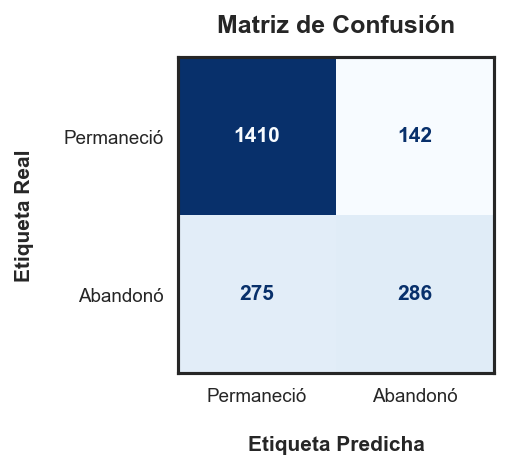

In [20]:
 plot_confusion_matrix(pipeline_boosting, X_test, y_test, figsize = (3.5,3.5), labels = ["Permaneció", "Abandonó"],
                       label_size = 10, annot_size = 10, label_pad = 14)

Es fundamental señalar que, a diferencia del `Random Forest`, el cual mantuvo una capacidad de detección de la clase positiva sumamente competitiva, el modelo `XGBoost` presentó una capacidad más baja para capturar la totalidad de los casos de abandono reales.

Al observar la matriz de confusión, se evidencia que el algoritmo omitió a $275$ clientes que efectivamente se fugaron, clasificándolos erróneamente como "Permaneció". Aunque este desempeño es técnicamente superior al de otros modelos de boosting, la presencia de estos falsos negativos indica que, bajo esta configuración, el modelo aún presenta limitaciones para identificar ciertos patrones de comportamiento que preceden al `churn`, lo que resulta en una sensibilidad menos robusta que la observada en arquitecturas de ensamble basadas en *bagging*.

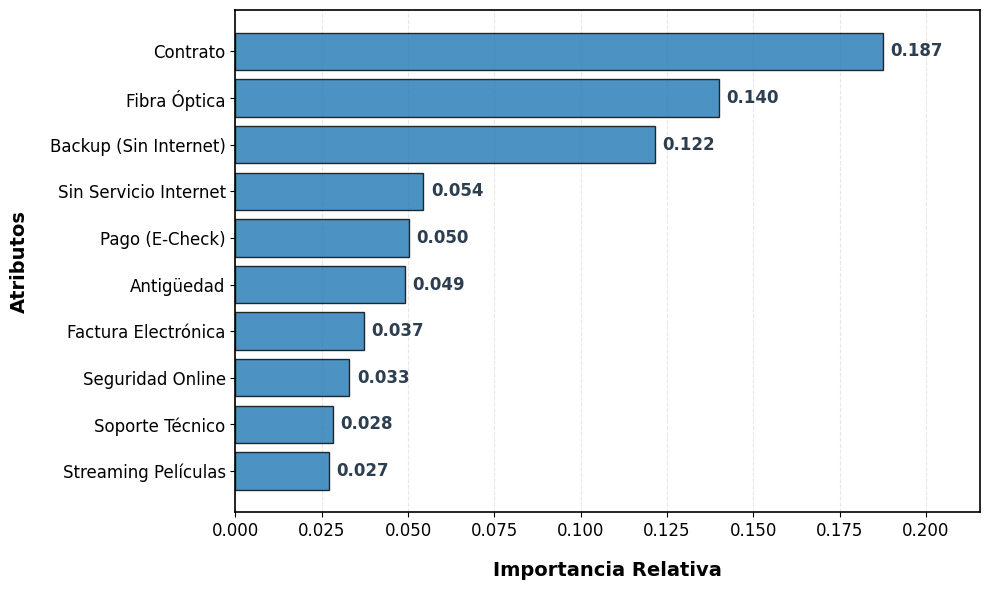

In [30]:
names = ["Contrato", "Fibra Óptica", "Backup (Sin Internet)", "Sin Servicio Internet",
    "Pago (E-Check)", "Antigüedad", "Factura Electrónica", "Seguridad Online", "Soporte Técnico", "Streaming Películas"]
plot_feature_importance(model=pipeline_boosting, X=X_test, feature_labels=names, top_k=10, spanish=True, figsize=(10, 6))

En lo que concierne a la importancia de las caracteristicas, el modelo `XGBoost` una jerarquía de importancia más distribuida que en el `Árbol de Decisión`, pero con un enfoque distinto al `Random Forest`. El Contrato se mantiene como el predictor principal, aunque con un peso menor que en los modelos anteriores, lo que indica que el algoritmo de boosting extrae información de una variedad más amplia de atributos. Destaca que la Fibra Óptica y el Backup (Sin Internet) escalan posiciones significativamente, superando en relevancia a la Antigüedad, la cual era secundaria en el Random Forest. Esta configuración sugiere que para `XGBoost`, las características técnicas del servicio contratado y los servicios adicionales tienen un impacto mayor en la ganancia de información que la trayectoria histórica del cliente o los montos de facturación.

##  CatBoost

Con el objetivo de profundizar en las arquitecturas de potenciación de gradiente, se integra el algoritmo de `CatBoost`. Este modelo se distingue por su tratamiento nativo y sofisticado de las variables categóricas y una arquitectura diseñada para mitigar el sesgo de predicción mediante un esquema de boosting ordenado. Siguiendo la metodología aplicada en las etapas anteriores, se procedió a evaluar el clasificador comparando los índices de rendimiento entre las fases de entrenamiento y prueba, centrando el análisis en la estabilidad del **F1-Score**.

In [48]:
file_path = RESULTS_PATH / "grid_results_cat_20260508_0543.csv"
df_catb = pd.read_csv(file_path)

In [49]:
model_cat = CatBoostClassifier(loss_function='Logloss', auto_class_weights='Balanced', random_seed=42, verbose=False,
    thread_count=-1, bootstrap_type='Bernoulli')

pipeline_cat = Pipeline(steps=[('preprocessor', preprocessor),('classifier', model_cat)])

param_grid_cat = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__depth': [3, 5, 7],
    'classifier__l2_leaf_reg': [1, 3, 7],
    'classifier__random_strength': [1, 5],
    'classifier__subsample': [0.4, 0.6, 0.8]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_cat = GridSearchCV(estimator=pipeline_cat, param_grid=param_grid_cat, 
                        scoring='f1', cv=cv_strategy, n_jobs=-1, verbose=2)

grid_cat.fit(X_train, y_train)
results_df_cat = pd.DataFrame(grid_cat.cv_results_)
cols_interes = [c for c in results_df_cat.columns if c.startswith('param_') or c.startswith('split')]
df_catb = results_df_cat[cols_interes]

display_top5(df_catb)

depth,l2_leaf_reg,learning_rate,n_estimators,random_strength,subsample,F1-Score
5,1,0.050000,100,5,0.400000,0.638 ± 0.044
5,7,0.050000,50,5,0.800000,0.637 ± 0.037
5,7,0.050000,100,5,0.400000,0.637 ± 0.037
7,1,0.050000,50,5,0.600000,0.636 ± 0.033
7,1,0.100000,50,5,0.400000,0.635 ± 0.050


Los resultados de la hiperparametrización para el `CatBoost` reflejan un desempeño altamente competitivo, alcanzando un **F1-Score** de $0.637 \pm 0.037$ en la configuración seleccionada. Si bien la primera opción de la malla presenta un valor central marginalmente superior, se ha optado por la segunda combinación del listado debido a su mayor capacidad de generalización y estabilidad.

Esta decisión técnica se fundamenta en la implementación de una regularización L2 más agresiva y una reducción a la mitad en el número de etapas de entrenamiento ($50$ estimadores). El hecho de que este modelo simplificado logre un rendimiento prácticamente idéntico al de configuraciones más densas confirma que una estructura parsimoniosa es suficiente para capturar los patrones revelevantes para la clasificación del `Churn`, mitigando el riesgo de sobreajuste y garantizando una frontera de decisión más robusta para el conjunto de datos analizado.

In [31]:
model_cat = CatBoostClassifier(n_estimators=50, depth=5, learning_rate=0.05, l2_leaf_reg=7,
                               random_strength=5, subsample=0.8, random_state=42, verbose=0, 
                               thread_count=2)

pipeline_cat_final = Pipeline(steps=[('preprocessor', preprocessor),('classifier', model_cat)])
pipeline_catboost = evaluate_model(pipeline=pipeline_cat_final, X_train=X_train, y_train=y_train, 
                                   X_test=X_test, y_test=y_test, spanish=True)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.806,0.801,0.006
Precisión,0.702,0.688,0.014
Sensibilidad,0.469,0.456,0.013
F1-Score,0.563,0.549,0.014
ROC-AUC,0.853,0.847,0.007


Al evaluar el desempeño de `CatBoost` en la muestra de prueba, se observa un rendimiento que guarda una estrecha similitud con los resultados obtenidos por `XGBoost`. El **F1-Score** se sitúa en $0.549$, mientras que el **ROC-AUC** alcanza un $0.847$, consolidando una capacidad predictiva consistente con las arquitecturas de potenciación de gradiente analizadas previamente. El modelo presenta una estabilidad notable, con diferencias mínimas entre las fases de entrenamiento y prueba, destacando una brecha de apenas $0.014$ en el **F1-Score** y de $0.007$ en el **ROC-AUC**. Esta consistencia confirma que la estrategia de regularización y el número reducido de estimadores seleccionados permiten una adecuada generalización. 


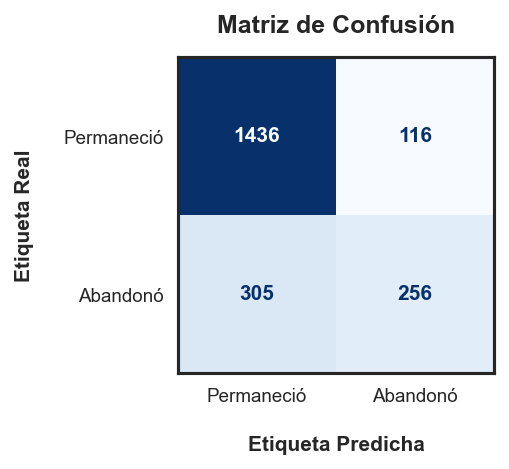

In [22]:
 plot_confusion_matrix(pipeline_catboost, X_test, y_test, figsize = (3.5,3.5), labels = ["Permaneció", "Abandonó"],
                       label_size = 10, annot_size = 10, label_pad = 14)

Al realizar un análisis más detallado, los resultados revelan que el modelo experimentó una mayor degradación de la sensibilidad en comparación con `XGBoost`. Esta diferencia sugiere que, bajo la configuración de parsimonia seleccionada, el mecanismo de ordered boosting de `CatBoost` actuó con un nivel de selectividad mayor, lo que, si bien garantiza una estabilidad superior en las métricas globales y evita el sobreajuste, establece un límite más rígido en la captura de la clase minoritaria dentro del conjunto de datos clínicos. En balance, aunque el rendimiento en el **F1-Score** y el **ROC-AUC** es sumamente cercano al de `XGBoost`, esta brecha en la sensibilidad marca una distinción técnica importante en la forma en que cada modelo gestiona el compromiso entre precisión y exhaustividad.

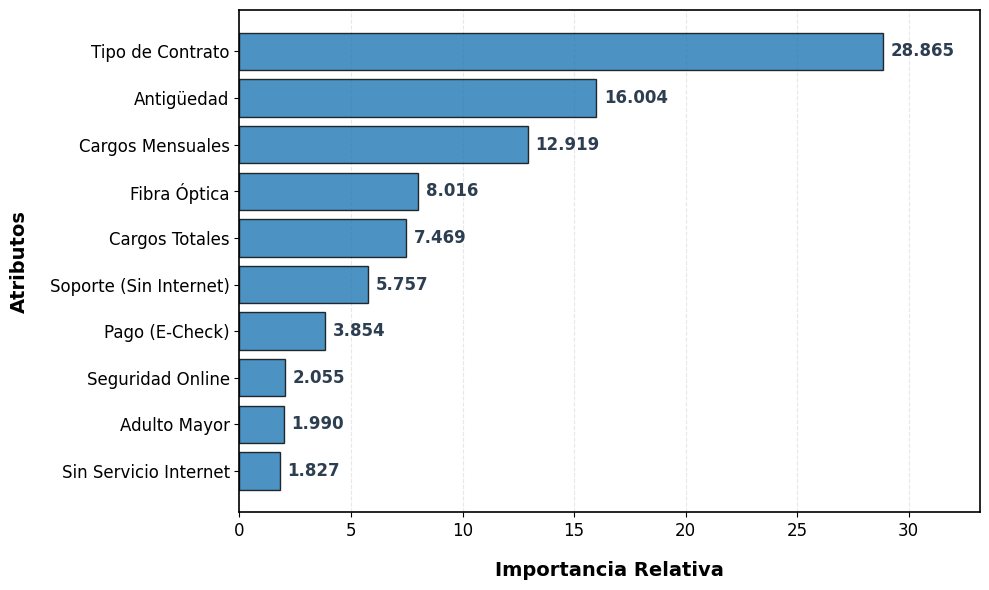

In [33]:
names = ["Tipo de Contrato", "Antigüedad", "Cargos Mensuales", "Fibra Óptica", "Cargos Totales",
    "Soporte (Sin Internet)", "Pago (E-Check)", "Seguridad Online", "Adulto Mayor", "Sin Servicio Internet"]
plot_feature_importance(model=pipeline_catboost, X=X_test, feature_labels=names, top_k=10, spanish=True, figsize=(10, 6))

En este caso, la importancia de las variables muestra un comportamiento que equilibra la estructura de los modelos de ensamble previos, posicionando nuevamente el Tipo de Contrato y la Antigüedad como los pilares fundamentales de la predicción. A diferencia de lo visto en `XGBoost`, este algoritmo otorga una relevancia mucho mayor a los Cargos Mensuales, sugiriendo que el impacto económico inmediato del servicio es un factor determinante para la ganancia de información. Los servicios técnicos como la Fibra Óptica y el historial de Cargos Totales aparecen en un nivel secundario, lo que indica que el modelo prioriza la estabilidad del acuerdo legal y la carga financiera recurrente para identificar el riesgo de abandono.

## LightGBM

Como cierre del estudio de las arquitecturas de boosting, se introduce el modelo de `LightGBM` (*Light Gradient Boosting Machine*). Este algoritmo se distingue por su innovadora técnica de crecimiento de árboles por hojas (*leaf-wise*) en lugar del crecimiento por niveles (*level-wise*) utilizado por la mayoría de los modelos convencionales, lo que permite una mayor eficiencia en el procesamiento de grandes volúmenes de datos y una reducción significativa en el consumo de memoria. Al implementar técnicas como el GOSS (*Gradient-based One-Side Sampling*), el modelo prioriza el aprendizaje sobre las instancias con gradientes más altos, optimizando la precisión del **F1-Score** sin comprometer la velocidad de cómputo.

In [58]:
file_path = RESULTS_PATH / "grid_results_lgbm_20260508_1946.csv"
df_lgbm = pd.read_csv(file_path)

In [59]:
model_lgbm = lgb.LGBMClassifier(boosting_type='gbdt', class_weight='balanced', device='gpu', random_state=42,
    importance_type='gain', verbosity=-1)

pipeline_lgbm = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model_lgbm)])

param_grid_lgbm = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__num_leaves': [7, 15, 31],
    'classifier__reg_lambda': [1, 3, 7],
    'classifier__subsample': [0.4, 0.6, 0.8],
    'classifier__subsample_freq': [1]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_lgbm = GridSearchCV(estimator=pipeline_lgbm, param_grid=param_grid_lgbm, scoring='f1', cv=cv_strategy, n_jobs=1,
    verbose=1)

grid_lgbm.fit(X_train, y_train)
results_df_lgbm = pd.DataFrame(grid_lgbm.cv_results_)
cols_interes = [c for c in results_df_lgbm.columns if c.startswith('param_') or c.startswith('split')]
df_lgbm = results_df_lgbm[cols_interes]

display_top5(df_lgbm)

learning_rate,max_depth,n_estimators,num_leaves,reg_lambda,subsample,subsample_freq,F1-Score
0.050000,7,200,31,3,0.400000,1,0.634 ± 0.036
0.010000,7,50,31,3,0.400000,1,0.633 ± 0.029
0.100000,7,200,31,1,0.600000,1,0.633 ± 0.029
0.010000,7,100,15,1,0.600000,1,0.633 ± 0.032
0.010000,7,100,15,7,0.600000,1,0.633 ± 0.031


A primera vista, los resultados de la hiperparametrización para `LightGBM` sugieren un desempeño tan competitivo como el de `XGBoost` o `CatBoost`, alcanzando niveles de **F1-Score** promedio superiores a $0.633$ en gran parte de la malla de búsqueda. Sin embargo, al estudiar su rendimiento en la muestra de prueba, se encontraron signos claros de inestabilidad y una alta sensibilidad a las variaciones en el número de estimadores y la tasa de aprendizaje.

Por consiguiente, se seleccionó la cuarta configuración de la tabla, la cual utiliza una tasa de aprendizaje de $0.01$ con $100$ estimadores y una estructura más contenida de solo $15$ hojas (*num_leaves*). Esta combinación ofrece el mejor equilibrio entre capacidad predictiva y control de la varianza; aunque otras opciones muestran valores centrales de F1-Score similares, esta elección prioriza la parsimonia del modelo para mitigar los efectos del sobreajuste observados en las versiones más complejas de este algoritmo.

In [34]:
warnings.filterwarnings('ignore')
model_lgbm = lgb.LGBMClassifier(n_estimators=100, max_depth=7, learning_rate=0.01, num_leaves = 15,
    reg_lambda=1, subsample=0.6, subsample_freq=1, random_state=42, n_jobs=2, importance_type='gain',
                               force_row_wise=True, verbosity=-1)

pipeline_lgbm_final = Pipeline(steps=[('preprocessor', preprocessor),('classifier', model_lgbm)])
pipeline_lightgbm = evaluate_model(pipeline=pipeline_lgbm_final, X_train=X_train, y_train=y_train, 
                                   X_test=X_test, y_test=y_test, spanish=True)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.798,0.784,0.015
Precisión,0.807,0.760,0.047†
Sensibilidad,0.316,0.271,0.045†
F1-Score,0.454,0.399,0.054†
ROC-AUC,0.862,0.845,0.017


Al evaluar el desempeño de `LightGBM` en la muestra de prueba, los resultados confirman una marcada inestabilidad en comparación con los modelos de boosting previos. En primera instancia, se observa una degradación masiva de las métricas principales, donde el **F1-Score** cae a un valor de $0.399$, lo que limita severamente la utilidad práctica del algoritmo en este conjunto de datos.

Asimismo, la tabla evidencia claros signos de sobreajuste (*overfitting*), con diferenciales que superan el umbral de tolerancia establecido para este experimento. Específicamente, la brecha de $0.054$ en el **F1-Score** (marcada con el símbolo $\dagger$) indica que el modelo no logra generalizar los patrones aprendidos durante el entrenamiento. Esta volatilidad sugiere que la arquitectura de crecimiento por hojas de `LightGBM` tiende a memorizar el ruido inherente a los datos, resultando en el clasificador con menor fiabilidad estadística de los evaluados hasta el momento.


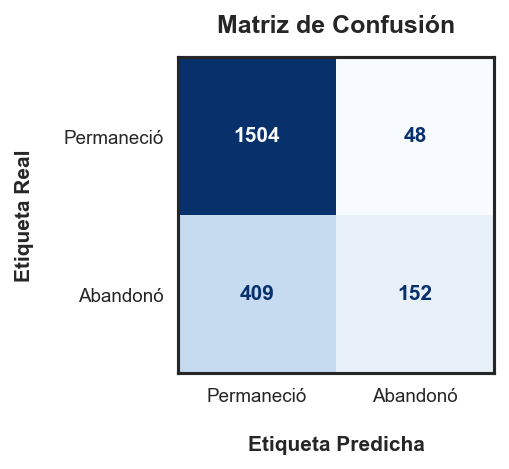

In [24]:
 plot_confusion_matrix(pipeline_lightgbm, X_test, y_test, figsize = (3.5,3.5), labels = ["Permaneció", "Abandonó"],
                       label_size = 10, annot_size = 10, label_pad = 14)

Un análisis detallado de la matriz de confusión revela que este modelo presenta la degradación más alta en la sensibilidad en lo que respecta a los modelos de *boosting* evaluados hasta el momento. Al observar los resultados en la muestra de prueba, la capacidad de identificar correctamente a los clientes que efectivamente abandonarán la empresa disminuye hasta alcanzar un valor de $0.271$, lo que representa una brecha de $0.045$ respecto a la fase de entrenamiento.

Esta caída en la capacidad de recuperación de casos reales indica que el modelo tiene dificultades para capturar a los usuarios en riesgo de fuga, tendiendo a omitir una cantidad significativa de la clase positiva bajo las condiciones de este conjunto de datos de comportamiento de clientes.

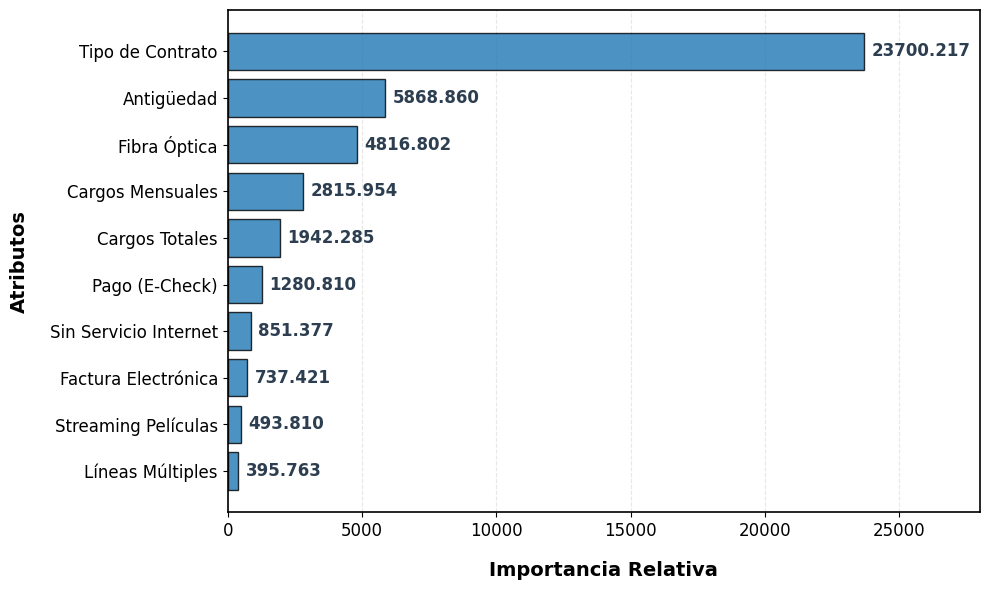

In [39]:
names = ["Tipo de Contrato", "Antigüedad", "Fibra Óptica", "Cargos Mensuales", "Cargos Totales", "Pago (E-Check)",
    "Sin Servicio Internet", "Factura Electrónica", "Streaming Películas", "Líneas Múltiples"]

plot_feature_importance(model=pipeline_lightgbm, X=X_test, feature_labels=names, top_k=10, spanish=True, figsize=(10, 6),
                        xlim = (0, 28000))

Para cerrar el análisis, en el modelo `LightGBM`, la ganancia de información se concentra de forma masiva en el Tipo de Contrato, el cual destaca como el predictor con mayor peso e influencia sobre el resto de las variables. Por detrás de este factor, la Antigüedad y la Fibra Óptica aparecen como los siguientes elementos de mayor relevancia, seguidos por la carga económica que representan los Cargos Mensuales y Totales. Este orden de importancia indica que el algoritmo prioriza la estabilidad del vínculo contractual y la permanencia del cliente por encima de otros servicios adicionales o métodos de pago para determinar la probabilidad de abandono.

# Evaluación de modelos

Una vez completado el ajuste y entrenamiento de los diversos algoritmos de clasificación bajo un esquema de integridad metodológica, se procede a la fase de evaluación comparativa. Esta etapa tiene como objetivo determinar cuál de los modelos presenta la mejor capacidad para identificar patrones de abandono de clientes (`churn`), garantizando al mismo tiempo una adecuada generalización frente a datos no observados de comportamiento de usuarios. Para ello, se analizan de forma conjunta las métricas de rendimiento obtenidas en el conjunto de prueba y se realiza un análisis estadístico mediante el *test de DeLong*, permitiendo establecer si las diferencias observadas en la potencia discriminativa de los modelos son estadísticamente significativas o si responden a la variabilidad inherente de las particiones.

Para dar inicio a la fase de evaluación, se presenta la Tabla de Rendimiento de los Modelos, consolidada a partir de la muestra de prueba tras haber mitigado cualquier rastro de *data leakage*. Este tablero de métricas permite contrastar la capacidad de clasificación de cada algoritmo bajo condiciones de integridad metodológica, sirviendo como punto de partida para identificar qué estructuras capturan mejor los patrones de riesgo de fuga en esta empresa de comunicaciones.

In [30]:
modelos_a_comparar = [
    ('Árbol de Decisión', pipeline_tree),
    ('Random Forest', pipeline_forest),
    ('XGBoost', pipeline_boosting),
    ('CatBoost', pipeline_catboost),
    ('LightGBM', pipeline_lightgbm )]
    
compare_models_table(modelos_a_comparar, X_test, y_test, spanish = True, sort_by = "F1-Score")

Modelo,Exactitud,Precisión,Sensibilidad,F1-Score,ROC-AUC
Random Forest,0.757,0.528,0.800,0.636,0.843
Árbol de Decisión,0.749,0.518,0.758,0.615,0.821
XGBoost,0.803,0.668,0.510,0.578,0.848
CatBoost,0.801,0.688,0.456,0.549,0.847
LightGBM,0.784,0.760,0.271,0.399,0.845


Al observar los resultados en la muestra de prueba, el análisis se centra en el **F1-Score** debido al desbalance de clases del fenómeno de churn. Bajo esta métrica, el `Random Forest` destaca como el modelo más robusto con un valor de $0.636$, seguido por el `Árbol de Decisión` con $0.615$. Esta jerarquía evidencia que las arquitecturas de *bagging* y árboles simples logran un equilibrio superior entre precisión y sensibilidad en comparación con los algoritmos de boosting evaluados. Por otro lado, la métrica **ROC-AUC** presenta una variabilidad reducida entre modelos (rango de $0.821$ a $0.848$), lo cual demuestra que una alta potencia discriminativa global no garantiza una identificación efectiva de los clientes en riesgo de fuga sin una calibración de umbrales.

En cuanto a la Sensibilidad (*Recall*), existe una degradación significativa en los modelos de *boosting* frente a los ensambles de promediado. Mientras que el Random Forest alcanza una sensibilidad de $0.800$, permitiendo capturar a la mayoría de los usuarios que efectivamente abandonarán la empresa, el `LightGBM` registra un valor crítico de $0.271$, lo que indica un sesgo hacia la clase mayoritaria.

Para formalizar la evaluación del poder predictivo, se presenta a continuación el análisis de las curvas ROC (*Receiver Operating Characteristic*), las cuales permiten visualizar y contrastar la capacidad discriminativa de los modelos evaluados. Con el objetivo de estudiar de forma más detallada el comportamiento de la curva ROC bajo condiciones de desbalance de clases, esta representación gráfica se vuelve fundamental para observar el balance entre la sensibilidad y la especificidad en todo el espectro de umbrales de decisión.


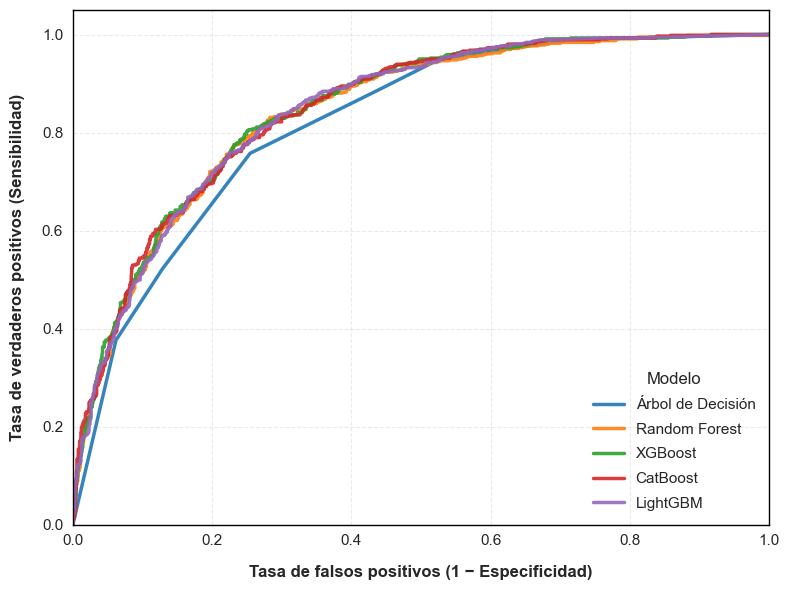

In [34]:
plot_roc_curves(modelos_a_comparar, X_test, y_test, spanish = True)

Al inspeccionar la gráfica de las curvas ROC, se evidencia que todos los modelos de ensamble superan consistentemente la capacidad discriminativa del `Árbol de Decisión` individual, el cual presenta una trayectoria más lineal y alejada del desempeño óptimo. No obstante, la diferencia entre las arquitecturas de *boosting* y *bagging* resulta casi imperceptible visualmente, ya que sus curvas se solapan a lo largo de casi todo el espectro de decisión.

No obstante, la proximidad entre las métricas de los modelos de alto rendimiento impide realizar una selección definitiva basada únicamente en la inspección visual o descriptiva. Declarar una superioridad técnica sin el sustento probabilístico adecuado comprometería la integridad del análisis. Por lo tanto, para determinar si las variaciones observadas en el AUC son estadísticamente sustanciales o si responden a la varianza inherente de los datos, se procede a aplicar el *test de DeLong*. Este procedimiento permitirá formalizar la comparación y establecer si existe una base sólida para la elección del modelo final.

:::{admonition} Nota Metodológica: Comparación de Curvas ROC y Test de DeLong
:class: note

Para determinar si las diferencias observadas en el área bajo la curva (AUC) entre los distintos modelos son estadísticamente significativas, se emplea el Test de DeLong. A diferencia de una comparación visual directa, este método permite contrastar dos o más curvas ROC correlacionadas (obtenidas de la misma muestra de prueba) mediante un enfoque no paramétrico basado en estadísticas U generalizadas.

Este procedimiento genera una matriz de covarianza para las estimaciones del AUC, permitiendo calcular un estadístico $Z$ para la diferencia de áreas:

$$Z = \frac{\hat{\theta}_1 - \hat{\theta}_2}{\sqrt{\text{Var}(\hat{\theta}_1 - \hat{\theta}_2)}}$$

Donde:

* $\hat{\theta}_i:$ Representa el estimador del área bajo la curva (AUC) para el modelo $i$.

* $\text{Var}(\hat{\theta}_1 - \hat{\theta}_2):$ Es la varianza de la diferencia entre las áreas, estimada mediante el método de DeLong.

Siguiendo los fundamentos de [DeLong et al. (1988)](https://doi.org/10.2307/2531595), se rechaza la hipótesis nula de igualdad entre modelos si el valor $p$ asociado es inferior al nivel de significancia establecido (típicamente $\alpha = 0.05$). En este análisis, se aplica además la corrección de [Holm (1979)](https://www.jstor.org/stable/4615733) para controlar la tasa de error por familia en las comparaciones múltiples, garantizando que el poder predictivo detectado no sea producto del azar.

:::

Al observar el análisis post-hoc basado en el *test de DeLong*, se confirma que todos los modelos de ensamble superan de manera estadísticamente significativa la capacidad discriminativa del `Árbol de Decisión` en términos de su AUC ($p < 0.001$). No obstante, este análisis también revela que, mientras las curvas ROC de los modelos de *boosting* y *bagging* convergen en valores estadísticamente similares entre sí ($p > 0.05$ en la todos de los pares), existe una degradación crítica en la sensibilidad (*Recall*) de los modelos de potenciación. Esta discrepancia técnica ilustra cómo, en situaciones de desbalance, el AUC puede resultar una métrica insuficiente para caracterizar el rendimiento, ya que un área bajo la curva superior no garantiza una identificación efectiva de los clientes en riesgo de fuga, ratificando la necesidad de priorizar métricas que capturen la utilidad operativa del modelo.

In [42]:
compare_delong(modelos_a_comparar, X_test, y_test, spanish = True)

Modelo 1,Modelo 2,AUC (L1),AUC (L2),Diferencia,SE,Z,p,LB,UB
Árbol de Decisión,XGBoost,0.821,0.848,-0.027,0.005,-5.759,<0.001***,-0.036,-0.018
Árbol de Decisión,CatBoost,0.821,0.847,-0.026,0.005,-5.502,<0.001***,-0.036,-0.017
Árbol de Decisión,LightGBM,0.821,0.845,-0.025,0.004,-6.483,<0.001***,-0.032,-0.017
Árbol de Decisión,Random Forest,0.821,0.843,-0.022,0.005,-4.429,<0.001***,-0.032,-0.012
Random Forest,XGBoost,0.843,0.848,-0.005,0.002,-2.331,0.119,-0.009,-0.001
Random Forest,CatBoost,0.843,0.847,-0.004,0.002,-1.744,0.406,-0.008,0.000
XGBoost,LightGBM,0.848,0.845,0.002,0.002,1.253,0.841,-0.001,0.006
Random Forest,LightGBM,0.843,0.845,-0.002,0.002,-0.919,1.000,-0.007,0.003
CatBoost,LightGBM,0.847,0.845,0.002,0.002,0.652,1.000,-0.003,0.007
XGBoost,CatBoost,0.848,0.847,0.001,0.002,0.325,1.000,-0.004,0.005


Dada toda la información recolectada y bajo un enfoque de utilidad operativa, el `Random Forest` se consolida como la solución óptima para el protocolo de retención al presentar el **F1-Score** más robusto ($0.636$) de la comparativa. Esta elección se sustenta en una mayor sensibilidad (*Recall*), logrando identificar correctamente a $449$ clientes que efectivamente abandonaron, lo que se traduce en una reducción de falsos negativos al disminuir los casos de fuga no detectados de $136$ a solo $112$. Aunque el volumen de falsos positivos es similar al del modelo base, la ganancia en la identificación de la clase positiva compensa este margen, ofreciendo una herramienta de detección mucho más confiable. En el contexto de una empresa de comunicaciones, esta precisión es crítica, ya que permite ejecutar estrategias de fidelización dirigidas y oportunas, minimizando la pérdida de usuarios en un mercado altamente competitivo y asegurando que los recursos de retención se asignen a quienes realmente presentan un riesgo inminente de abandono.